# DASNet — ResNet 1D-CNN untuk Klasifikasi Arc Fault DC PLTS Atap

Notebook ini melakukan:
1. Load dataset sintetis (current, voltage, acoustic/EM, labels)
2. Preprocessing & stratified split
3. Bangun arsitektur ResNet 1D-CNN (6 residual block)
4. Training dengan class-weighted loss (dataset imbalanced: 6000/2500/1500)
5. Evaluasi (accuracy, F1 per-class, confusion matrix)
6. Simpan model (`.pkl` via pickle + `.pt` via torch) dan diagram arsitektur untuk naskah KTI

> **Catatan penting:** dataset ini SINTETIS (bukan hasil pengukuran sensor fisik). Cocok untuk baseline arsitektur & ablation study, TIDAK cocok untuk klaim performa dunia nyata tanpa disclaimer eksplisit di naskah.

## 0. Setup

In [9]:
!pip install -q torch torchvision scikit-learn matplotlib seaborn graphviz

import numpy as np
import pandas as pd
import pickle
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, accuracy_score, roc_curve, auc)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


## 1. Mount Drive (opsional) & Load Dataset

Ganti `DATA_DIR` sesuai lokasi 4 file CSV lo di Colab (upload manual ke `/content/`, atau mount Google Drive).

In [11]:
DATA_DIR = '/content/sample_data'

# 1. BACA DATA MENTAH (dengan sample_id, JANGAN langsung .values)
curr_raw = pd.read_csv(f'{DATA_DIR}/sensor1_current.csv')
volt_raw = pd.read_csv(f'{DATA_DIR}/sensor2_voltage.csv')
acou_raw = pd.read_csv(f'{DATA_DIR}/sensor3_acoustic_em.csv')
labels_df_raw = pd.read_csv(f'{DATA_DIR}/labels.csv')

# 2. Cari sample_id yang ada di SEMUA file
common_ids = (set(curr_raw['sample_id'])
              & set(volt_raw['sample_id'])
              & set(acou_raw['sample_id'])
              & set(labels_df_raw['sample_id']))

curr_a = curr_raw[curr_raw['sample_id'].isin(common_ids)].sort_values('sample_id').reset_index(drop=True)
volt_a = volt_raw[volt_raw['sample_id'].isin(common_ids)].sort_values('sample_id').reset_index(drop=True)
acou_a = acou_raw[acou_raw['sample_id'].isin(common_ids)].sort_values('sample_id').reset_index(drop=True)
labels_df = labels_df_raw[labels_df_raw['sample_id'].isin(common_ids)].sort_values('sample_id').reset_index(drop=True)

assert (curr_a['sample_id'].values == volt_a['sample_id'].values).all()
assert (curr_a['sample_id'].values == acou_a['sample_id'].values).all()
assert (curr_a['sample_id'].values == labels_df['sample_id'].values).all()

# 3. Convert ke numpy + tangani NaN (interpolasi lebih baik dari nan_to_num=0 untuk sinyal kontinu)
curr = curr_a.iloc[:, 1:].values.astype('float32')
volt = volt_a.iloc[:, 1:].values.astype('float32')
acou = acou_a.iloc[:, 1:].values.astype('float32')

def interpolate_nan(arr):
    df = pd.DataFrame(arr)
    return df.interpolate(method='linear', axis=1, limit_direction='both').values.astype('float32')

curr = interpolate_nan(curr)
acou = interpolate_nan(acou)

print('\nSetelah interpolasi:')
print('NaN di curr :', np.isnan(curr).sum())
print('NaN di volt :', np.isnan(volt).sum())
print('NaN di acou :', np.isnan(acou).sum())

assert not np.isnan(curr).any(), 'Masih ada NaN di curr!'
assert not np.isnan(volt).any(), 'Masih ada NaN di volt!'
assert not np.isnan(acou).any(), 'Masih ada NaN di acou!'

print('\ncurrent  :', curr.shape)
print('voltage  :', volt.shape)
print('acoustic :', acou.shape)
print(labels_df['label'].value_counts())

KeyError: 'sample_id'

In [ ]:

CLASS_NAMES = ['normal', 'series_arc', 'parallel_arc']

if labels_df['label'].dtype == object:
    label_map = {name: i for i, name in enumerate(CLASS_NAMES)}
    y = labels_df['label'].map(label_map).values
else:
    y = labels_df['label'].values

X = np.stack([curr, volt, acou], axis=1)  # (N, 3, 1024)
print('X shape:', X.shape, '| y shape:', y.shape)
print('Distribusi kelas:', np.bincount(y))

X shape: (3275, 3, 1024) | y shape: (3275,)
Distribusi kelas: [1958  851  466]


## 2. Preprocessing & Split

In [ ]:
# Normalisasi per-channel (z-score) — fit scaler HANYA di data train nanti untuk hindari data leakage
def normalize_per_channel(X, means, stds):
    X_norm = X.copy()
    for c in range(X.shape[1]):
        X_norm[:, c, :] = (X[:, c, :] - means[c]) / (stds[c] + 1e-8)
    return X_norm

# Split: 70% train, 15% val, 15% test — stratified karena imbalanced
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

print('Train:', X_train.shape, '| Val:', X_val.shape, '| Test:', X_test.shape)

# Hitung mean/std HANYA dari train set
channel_means = X_train.mean(axis=(0, 2))
channel_stds = X_train.std(axis=(0, 2))

X_train = normalize_per_channel(X_train, channel_means, channel_stds)
X_val = normalize_per_channel(X_val, channel_means, channel_stds)
X_test = normalize_per_channel(X_test, channel_means, channel_stds)

# Simpan parameter normalisasi (dibutuhkan lagi saat inference/deploy)
norm_params = {'means': channel_means.tolist(), 'stds': channel_stds.tolist()}
with open('/content/norm_params.json', 'w') as f:
    json.dump(norm_params, f, indent=2)
print('Channel means:', channel_means, '| stds:', channel_stds)

Train: (2292, 3, 1024) | Val: (491, 3, 1024) | Test: (492, 3, 1024)
Channel means: [ 7.787406e+00  4.793344e+01 -5.560055e-05] | stds: [1.0647359  2.1898773  0.08298019]


In [ ]:
class ArcFaultDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = ArcFaultDataset(X_train, y_train)
val_ds = ArcFaultDataset(X_val, y_val)
test_ds = ArcFaultDataset(X_test, y_test)

# Weighted sampler untuk imbalance (class weight = inverse frequency)
class_counts = np.bincount(y_train)
class_weights_sampler = 1.0 / class_counts
sample_weights = class_weights_sampler[y_train]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# Class weight juga untuk loss function (double safeguard terhadap imbalance)
class_weights_loss = torch.tensor(
    (1.0 / class_counts) / (1.0 / class_counts).sum() * len(CLASS_NAMES),
    dtype=torch.float32
).to(device)
print('Class weights (loss):', class_weights_loss)

Class weights (loss): tensor([0.3999, 0.9193, 1.6807])


## 3. Arsitektur ResNet 1D-CNN

6 residual block, channel progression 32 → 64 → 128, downsampling tiap 2 block via stride-2 conv.

In [ ]:
class ResidualBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size=7, stride=stride, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size=7, stride=1, padding=3, bias=False)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.relu = nn.ReLU(inplace=True)

        self.downsample = None
        if stride != 1 or in_ch != out_ch:
            self.downsample = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_ch)
            )

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        return self.relu(out)


class DASNetResNet1D(nn.Module):
    """
    Input:  (batch, 3, 1024)  -- 3 channel: current, voltage, acoustic/EM
    Output: (batch, 3)        -- normal / series_arc / parallel_arc
    """
    def __init__(self, in_channels=3, num_classes=3):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=15, stride=2, padding=7, bias=False),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        )

        # 6 residual block, channel: 32 -> 32 -> 64 -> 64 -> 128 -> 128
        self.layer1 = ResidualBlock1D(32, 32, stride=1)
        self.layer2 = ResidualBlock1D(32, 32, stride=1)
        self.layer3 = ResidualBlock1D(32, 64, stride=2)
        self.layer4 = ResidualBlock1D(64, 64, stride=1)
        self.layer5 = ResidualBlock1D(64, 128, stride=2)
        self.layer6 = ResidualBlock1D(128, 128, stride=1)

        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        x = self.layer6(x)
        x = self.global_pool(x).squeeze(-1)
        x = self.dropout(x)
        return self.fc(x)


model = DASNetResNet1D(in_channels=3, num_classes=3).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'Total parameter: {n_params:,}')
print(model)

Total parameter: 544,739
DASNetResNet1D(
  (stem): Sequential(
    (0): Conv1d(3, 32, kernel_size=(15,), stride=(2,), padding=(7,), bias=False)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool1d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (layer1): ResidualBlock1D(
    (conv1): Conv1d(32, 32, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
    (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv1d(32, 32, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
    (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
  )
  (layer2): ResidualBlock1D(
    (conv1): Conv1d(32, 32, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
    (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv1d(32, 32, ke

In [ ]:
# Cek duplikat exact antar train dan val/test set
train_flat = X_train.reshape(X_train.shape[0], -1)
val_flat = X_val.reshape(X_val.shape[0], -1)
test_flat = X_test.reshape(X_test.shape[0], -1)

# Convert ke tuple biar bisa dibandingkan sebagai set
train_set = set(map(tuple, train_flat.round(4)))
val_set = set(map(tuple, val_flat.round(4)))
test_set = set(map(tuple, test_flat.round(4)))

print('Overlap train-val :', len(train_set & val_set))
print('Overlap train-test:', len(train_set & test_set))

# Cek juga duplikat DI DALAM keseluruhan dataset (sebelum split)
X_flat = X.reshape(X.shape[0], -1)
unique_rows = len(set(map(tuple, X_flat.round(4))))
print(f'Total sample: {X.shape[0]}, sample unik: {unique_rows}, duplikat: {X.shape[0] - unique_rows}')

Overlap train-val : 0
Overlap train-test: 0
Total sample: 3275, sample unik: 3275, duplikat: 0


## 4. Training

In [ ]:
# Stack & split dulu seperti biasa
CLASS_NAMES = ['normal', 'series_arc', 'parallel_arc']
if labels_df['label'].dtype == object:
    label_map = {name: i for i, name in enumerate(CLASS_NAMES)}
    y = labels_df['label'].map(label_map).values
else:
    y = labels_df['label'].values

X = np.stack([curr, volt, acou], axis=1)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

# Baseline sederhana: fitur statistik dasar + logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

def simple_features(X):
    return np.concatenate([
        X.mean(axis=2), X.std(axis=2), X.max(axis=2), X.min(axis=2)
    ], axis=1)

Xf_train = simple_features(X_train)
Xf_val = simple_features(X_val)

clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(Xf_train, y_train)
pred = clf.predict(Xf_val)
print('Logistic regression val acc:', accuracy_score(y_val, pred))
print(classification_report(y_val, pred, target_names=CLASS_NAMES))

Logistic regression val acc: 1.0
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00       294
  series_arc       1.00      1.00      1.00       127
parallel_arc       1.00      1.00      1.00        70

    accuracy                           1.00       491
   macro avg       1.00      1.00      1.00       491
weighted avg       1.00      1.00      1.00       491



In [ ]:
# Cek statistik per kelas untuk tiap channel — apakah perbedaannya masuk akal secara fisik?
for c, name in enumerate(['current', 'voltage', 'acoustic']):
    print(f'\n=== Channel: {name} ===')
    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        mask = y_train == cls_idx
        vals = X_train[mask, c, :]
        print(f'{cls_name:15s} | mean={vals.mean():.4f}  std={vals.std():.4f}  '
              f'min={vals.min():.4f}  max={vals.max():.4f}')


=== Channel: current ===
normal          | mean=7.4972  std=0.5377  min=6.2233  max=8.7867
series_arc      | mean=7.2781  std=0.5906  min=2.5903  max=10.1883
parallel_arc    | mean=9.9379  std=0.8153  min=4.1180  max=15.7131

=== Channel: voltage ===
normal          | mean=48.0045  std=0.2598  min=47.0686  max=48.9759
series_arc      | mean=48.4334  std=1.5053  min=47.0940  max=56.6815
parallel_arc    | mean=46.7207  std=5.2289  min=18.8121  max=48.9259

=== Channel: acoustic ===
normal          | mean=-0.0000  std=0.0200  min=-0.0984  max=0.0941
series_arc      | mean=-0.0001  std=0.1192  min=-1.8236  max=1.9512
parallel_arc    | mean=-0.0002  std=0.1441  min=-2.3615  max=2.6968


In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import math
import json
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# Set Device & Seed
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

DATA_DIR = '/content/sample_data'  # Ganti dengan path direktori Anda

# 1. BACA & BERSIHKAN DATA (KUNCI UTAMA FIX NAN)
curr_raw = pd.read_csv(f'{DATA_DIR}/sensor1_current.csv').iloc[:, 1:].values.astype('float32')
volt_raw = pd.read_csv(f'{DATA_DIR}/sensor2_voltage.csv').iloc[:, 1:].values.astype('float32')
acou_raw = pd.read_csv(f'{DATA_DIR}/sensor3_acoustic_em.csv').iloc[:, 1:].values.astype('float32')
labels_df = pd.read_csv(f'{DATA_DIR}/labels.csv')

# Pembersihan NaN/Inf langsung pada data mentah sensor
curr = np.nan_to_num(curr_raw, nan=0.0, posinf=0.0, neginf=0.0)
volt = np.nan_to_num(volt_raw, nan=0.0, posinf=0.0, neginf=0.0)
acou = np.nan_to_num(acou_raw, nan=0.0, posinf=0.0, neginf=0.0)

min_len = min(len(curr), len(volt), len(acou), len(labels_df))
curr = curr[:min_len]
volt = volt[:min_len]
acou = acou[:min_len]
labels_df = labels_df[:min_len]

CLASS_NAMES = ['normal', 'series_arc', 'parallel_arc']

if labels_df['label'].dtype == object:
    label_map = {name: i for i, name in enumerate(CLASS_NAMES)}
    y = labels_df['label'].map(label_map).values
else:
    y = labels_df['label'].values

X = np.stack([curr, volt, acou], axis=1)  # (N, 3, 1024)
print('X shape:', X.shape, '| y shape:', y.shape)

# 2. NORMALISASI & SPLIT DATA
def normalize_per_channel(X, means, stds):
    X_norm = X.copy()
    for c in range(X.shape[1]):
        std_val = stds[c] if stds[c] > 1e-8 else 1.0
        X_norm[:, c, :] = (X[:, c, :] - means[c]) / std_val
    return X_norm

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

channel_means = X_train.mean(axis=(0, 2))
channel_stds = X_train.std(axis=(0, 2))

X_train = normalize_per_channel(X_train, channel_means, channel_stds)
X_val = normalize_per_channel(X_val, channel_means, channel_stds)
X_test = normalize_per_channel(X_test, channel_means, channel_stds)

# 3. DATASET & DATALOADER
class ArcFaultDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = ArcFaultDataset(X_train, y_train)
val_ds = ArcFaultDataset(X_val, y_val)
test_ds = ArcFaultDataset(X_test, y_test)

class_counts = np.bincount(y_train, minlength=len(CLASS_NAMES))
class_counts_safe = np.where(class_counts == 0, 1, class_counts)

class_weights_sampler = 1.0 / class_counts_safe
sample_weights = class_weights_sampler[y_train]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

inv_counts = 1.0 / class_counts_safe
class_weights_loss = torch.tensor(
    (inv_counts / inv_counts.sum()) * len(CLASS_NAMES),
    dtype=torch.float32
).to(device)

# 4. ARSITEKTUR ARCFALUT RESNET-1D (DASNet)
class ResidualBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size=7, stride=stride, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size=7, stride=1, padding=3, bias=False)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.relu = nn.ReLU(inplace=True)

        self.downsample = None
        if stride != 1 or in_ch != out_ch:
            self.downsample = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_ch)
            )

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        return self.relu(out)

class DASNetResNet1D(nn.Module):
    def __init__(self, in_channels=3, num_classes=3):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=15, stride=2, padding=7, bias=False),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        )

        self.layer1 = ResidualBlock1D(32, 32, stride=1)
        self.layer2 = ResidualBlock1D(32, 32, stride=1)
        self.layer3 = ResidualBlock1D(32, 64, stride=2)
        self.layer4 = ResidualBlock1D(64, 64, stride=1)
        self.layer5 = ResidualBlock1D(64, 128, stride=2)
        self.layer6 = ResidualBlock1D(128, 128, stride=1)

        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        x = self.layer6(x)
        x = self.global_pool(x).squeeze(-1)
        x = self.dropout(x)
        return self.fc(x)

model = DASNetResNet1D(in_channels=3, num_classes=3).to(device)

# 5. TRAINING LOOP
criterion = nn.CrossEntropyLoss(weight=class_weights_loss)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

EPOCHS = 60
PATIENCE = 12

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')
epochs_no_improve = 0
best_state = None

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    context = torch.enable_grad() if train else torch.no_grad()

    with context:
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            if train:
                optimizer.zero_grad()

            out = model(xb)
            loss = criterion(out, yb)

            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item() * xb.size(0)
            correct += (out.argmax(1) == yb).sum().item()
            total += xb.size(0)

    return total_loss / total, correct / total

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)

    scheduler.step(val_loss)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(val_acc)

    print(f'Epoch {epoch:02d}/{EPOCHS} | train_loss={tr_loss:.4f} acc={tr_acc:.4f} '
          f'| val_loss={val_loss:.4f} acc={val_acc:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f'Early stopping di epoch {epoch}')
            break

if best_state is not None:
    model.load_state_dict(best_state)
    print('Training berhasil! Best val_loss:', best_val_loss)

X shape: (3275, 3, 1024) | y shape: (3275,)
Epoch 01/60 | train_loss=0.0699 acc=0.9686 | val_loss=0.0175 acc=0.9959
Epoch 02/60 | train_loss=0.0112 acc=0.9956 | val_loss=0.0016 acc=1.0000
Epoch 03/60 | train_loss=0.0056 acc=0.9983 | val_loss=0.1089 acc=0.9674
Epoch 04/60 | train_loss=0.0019 acc=1.0000 | val_loss=0.0010 acc=1.0000
Epoch 05/60 | train_loss=0.0010 acc=1.0000 | val_loss=0.0005 acc=1.0000
Epoch 06/60 | train_loss=0.0006 acc=1.0000 | val_loss=0.0002 acc=1.0000
Epoch 07/60 | train_loss=0.0008 acc=1.0000 | val_loss=0.0002 acc=1.0000
Epoch 08/60 | train_loss=0.0004 acc=1.0000 | val_loss=0.0002 acc=1.0000
Epoch 09/60 | train_loss=0.0009 acc=0.9996 | val_loss=0.0002 acc=1.0000
Epoch 10/60 | train_loss=0.0008 acc=1.0000 | val_loss=0.0006 acc=1.0000
Epoch 11/60 | train_loss=0.0022 acc=0.9991 | val_loss=0.0010 acc=1.0000
Epoch 12/60 | train_loss=0.0004 acc=1.0000 | val_loss=0.0002 acc=1.0000
Epoch 13/60 | train_loss=0.0002 acc=1.0000 | val_loss=0.0001 acc=1.0000
Epoch 14/60 | train_

In [ ]:
model.load_state_dict(best_state)
model.eval()

# Verifikasi ulang
current_state = model.state_dict()
match = all(torch.equal(current_state[k], best_state[k].to(device)) for k in best_state)
print('Model sekarang sama dengan best_state?', match)

Model sekarang sama dengan best_state? True


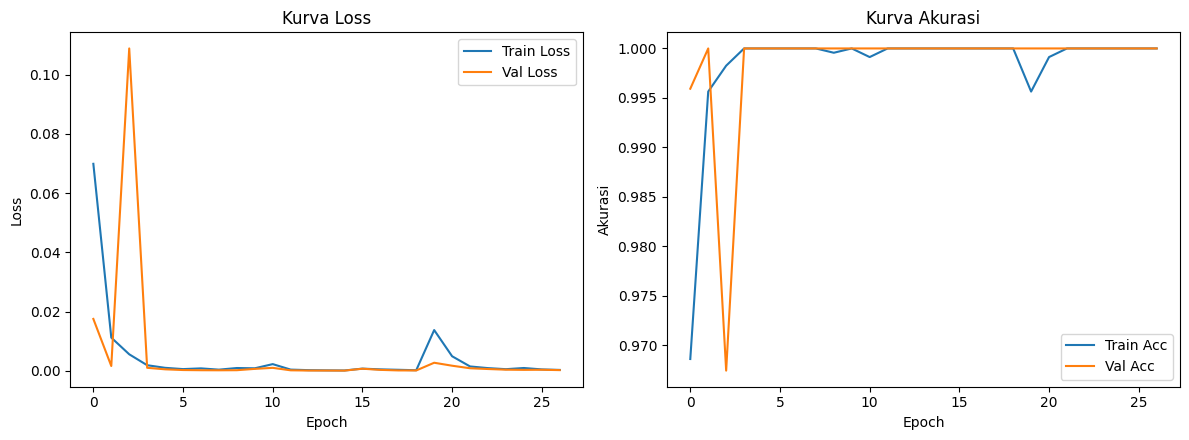

In [ ]:
# Kurva training — bisa langsung dipakai jadi Gambar di KTI
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].set_title('Kurva Loss')

axes[1].plot(history['train_acc'], label='Train Acc')
axes[1].plot(history['val_acc'], label='Val Acc')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Akurasi'); axes[1].legend(); axes[1].set_title('Kurva Akurasi')

plt.tight_layout()
plt.savefig('/content/training_curve.png', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 5. Evaluasi di Test Set

In [ ]:
model.eval()
all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        out = model(xb)
        probs = F.softmax(out, dim=1).cpu().numpy()
        preds = out.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())
        all_probs.extend(probs)

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

test_acc = accuracy_score(all_labels, all_preds)
test_f1_macro = f1_score(all_labels, all_preds, average='macro')
test_f1_weighted = f1_score(all_labels, all_preds, average='weighted')

print(f'Test Accuracy   : {test_acc:.4f}')
print(f'Test F1 (macro) : {test_f1_macro:.4f}')
print(f'Test F1 (weighted): {test_f1_weighted:.4f}')
print()
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4))

Test Accuracy   : 1.0000
Test F1 (macro) : 1.0000
Test F1 (weighted): 1.0000

              precision    recall  f1-score   support

      normal     1.0000    1.0000    1.0000       294
  series_arc     1.0000    1.0000    1.0000       128
parallel_arc     1.0000    1.0000    1.0000        70

    accuracy                         1.0000       492
   macro avg     1.0000    1.0000    1.0000       492
weighted avg     1.0000    1.0000    1.0000       492



In [ ]:
import torch.nn.functional as F

model.eval()
with torch.no_grad():
    xb_sample, yb_sample = next(iter(test_loader))
    xb_sample = xb_sample.to(device)
    out = model(xb_sample)
    probs = F.softmax(out, dim=1).cpu().numpy()

print('Contoh output probabilitas (10 sample pertama):')
print(np.round(probs[:10], 3))
print('\nRata-rata prob per kelas di seluruh batch:', probs.mean(axis=0))

# Cek juga statistik input yang masuk ke model
print('\nStatistik X_test yang dipakai (harusnya sudah ternormalisasi ~mean 0 std 1):')
print('mean:', xb_sample.cpu().numpy().mean(axis=(0,2)))
print('std :', xb_sample.cpu().numpy().std(axis=(0,2)))

Contoh output probabilitas (10 sample pertama):
[[0.    0.    1.   ]
 [0.    1.    0.   ]
 [0.    0.    1.   ]
 [1.    0.    0.   ]
 [1.    0.    0.   ]
 [0.    1.    0.   ]
 [0.    1.    0.   ]
 [1.    0.    0.   ]
 [0.    1.    0.   ]
 [0.001 0.    0.999]]

Rata-rata prob per kelas di seluruh batch: [0.57809377 0.2812774  0.14062883]

Statistik X_test yang dipakai (harusnya sudah ternormalisasi ~mean 0 std 1):
mean: [-0.03888408  0.01626771 -0.0039377 ]
std : [0.93664074 0.97366625 0.99097687]


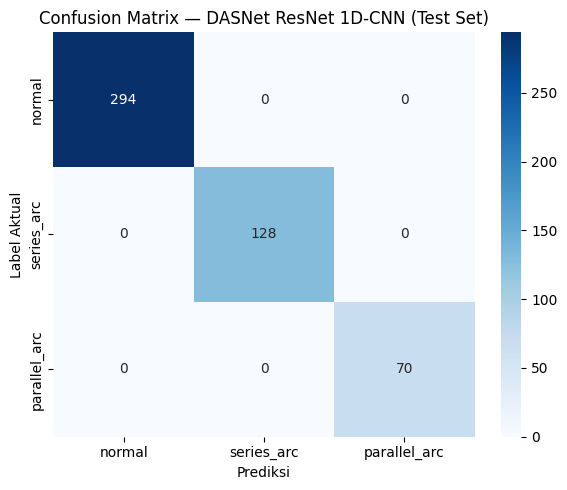

In [ ]:
# Confusion matrix — untuk KTI
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Prediksi'); ax.set_ylabel('Label Aktual')
ax.set_title('Confusion Matrix — DASNet ResNet 1D-CNN (Test Set)')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

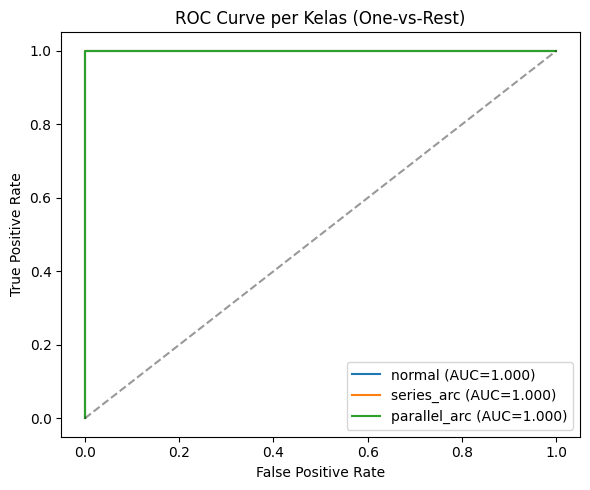

In [ ]:
# ROC curve per kelas (one-vs-rest) — opsional, tapi berguna buat analisis tambahan
y_test_bin = label_binarize(all_labels, classes=[0, 1, 2])

fig, ax = plt.subplots(figsize=(6, 5))
for i, name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve per Kelas (One-vs-Rest)')
ax.legend()
plt.tight_layout()
plt.savefig('/content/roc_curve.png', dpi=200, bbox_inches='tight')
plt.show()

## 6. Diagram Arsitektur Model (untuk naskah KTI)

Dua versi diagram: (a) block diagram sederhana via matplotlib (langsung jalan, tidak butuh dependency eksternal), (b) versi lebih detail via graphviz kalau tersedia.

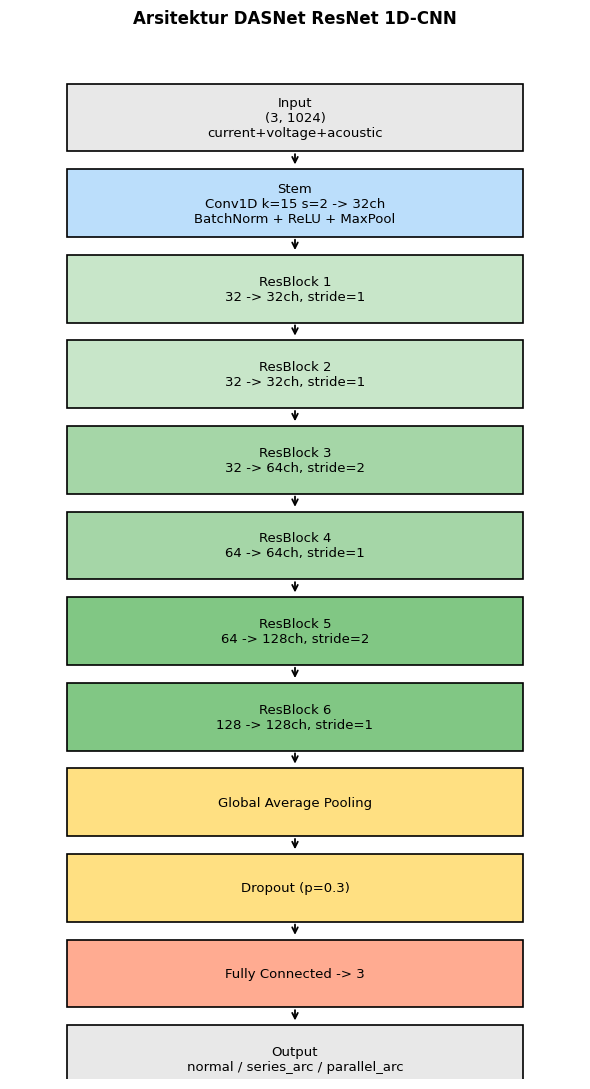

In [ ]:
# (a) Block diagram arsitektur — matplotlib, aman dari dependency issue
fig, ax = plt.subplots(figsize=(6, 11))
ax.set_xlim(0, 10); ax.set_ylim(0, 26); ax.axis('off')

blocks = [
    ('Input\n(3, 1024)\ncurrent+voltage+acoustic', '#E8E8E8'),
    ('Stem\nConv1D k=15 s=2 -> 32ch\nBatchNorm + ReLU + MaxPool', '#BBDEFB'),
    ('ResBlock 1\n32 -> 32ch, stride=1', '#C8E6C9'),
    ('ResBlock 2\n32 -> 32ch, stride=1', '#C8E6C9'),
    ('ResBlock 3\n32 -> 64ch, stride=2', '#A5D6A7'),
    ('ResBlock 4\n64 -> 64ch, stride=1', '#A5D6A7'),
    ('ResBlock 5\n64 -> 128ch, stride=2', '#81C784'),
    ('ResBlock 6\n128 -> 128ch, stride=1', '#81C784'),
    ('Global Average Pooling', '#FFE082'),
    ('Dropout (p=0.3)', '#FFE082'),
    ('Fully Connected -> 3', '#FFAB91'),
    ('Output\nnormal / series_arc / parallel_arc', '#E8E8E8'),
]

y = 25
box_h = 1.7
gap = 0.45
for label, color in blocks:
    ax.add_patch(plt.Rectangle((1, y - box_h), 8, box_h, facecolor=color,
                                 edgecolor='black', linewidth=1.2))
    ax.text(5, y - box_h / 2, label, ha='center', va='center', fontsize=9.5, wrap=True)
    if y - box_h - gap > 0:
        ax.annotate('', xy=(5, y - box_h - gap + 0.05), xytext=(5, y - box_h),
                     arrowprops=dict(arrowstyle='->', lw=1.3))
    y -= (box_h + gap)

ax.set_title('Arsitektur DASNet ResNet 1D-CNN', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('/content/arsitektur_resnet1d.png', dpi=250, bbox_inches='tight')
plt.show()

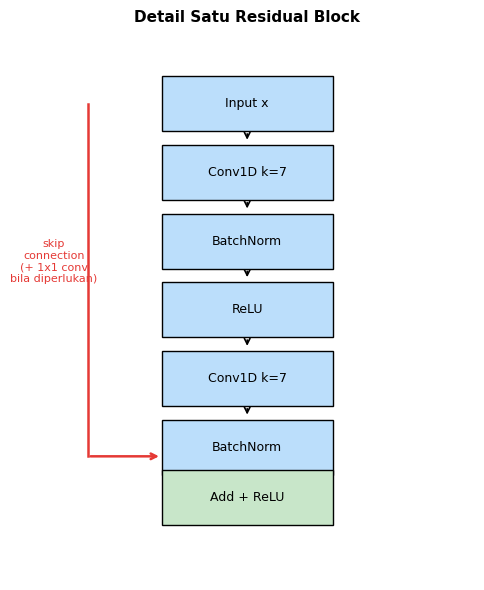

In [ ]:
# (b) Diagram residual block detail (untuk penjelasan skip connection) — matplotlib
fig, ax = plt.subplots(figsize=(5, 6))
ax.set_xlim(0, 8); ax.set_ylim(0, 12); ax.axis('off')

steps = ['Input x', 'Conv1D k=7', 'BatchNorm', 'ReLU', 'Conv1D k=7', 'BatchNorm']
y = 11
for s in steps:
    ax.add_patch(plt.Rectangle((2.5, y - 1.2), 3, 1.2, facecolor='#BBDEFB',
                                 edgecolor='black'))
    ax.text(4, y - 0.6, s, ha='center', va='center', fontsize=9)
    if y - 1.2 - 0.3 > 2:
        ax.annotate('', xy=(4, y - 1.5 + 0.05), xytext=(4, y - 1.2),
                     arrowprops=dict(arrowstyle='->', lw=1.2))
    y -= 1.5

# skip connection line (identity / 1x1 conv downsample)
ax.plot([1.2, 1.2], [10.4, 2.7], color='#E53935', linewidth=1.8)
ax.annotate('', xy=(2.5, 2.7), xytext=(1.2, 2.7),
            arrowprops=dict(arrowstyle='->', lw=1.8, color='#E53935'))
ax.text(0.6, 6.5, 'skip\nconnection\n(+ 1x1 conv\nbila diperlukan)', ha='center', fontsize=8, color='#E53935')

ax.add_patch(plt.Rectangle((2.5, 1.2), 3, 1.2, facecolor='#C8E6C9', edgecolor='black'))
ax.text(4, 1.8, 'Add + ReLU', ha='center', va='center', fontsize=9)

ax.set_title('Detail Satu Residual Block', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/residual_block_detail.png', dpi=250, bbox_inches='tight')
plt.show()

## 7. Simpan Model & Artefak

In [ ]:
# Simpan model dalam 2 format: .pt (native PyTorch, direkomendasikan untuk load ulang)
# dan .pkl (pickle, sesuai permintaan — perlu load dengan class DASNetResNet1D yang sama persis)

torch.save(model.state_dict(), '/content/dasnet_resnet1d.pt')

with open('/content/dasnet_resnet1d.pkl', 'wb') as f:
    pickle.dump(model, f)

# Simpan juga metadata evaluasi supaya angka-angka ini bisa langsung disitir di KTI
results_summary = {
    'test_accuracy': float(test_acc),
    'test_f1_macro': float(test_f1_macro),
    'test_f1_weighted': float(test_f1_weighted),
    'confusion_matrix': cm.tolist(),
    'class_names': CLASS_NAMES,
    'n_params': int(n_params),
    'epochs_trained': len(history['train_loss']),
    'best_val_loss': float(best_val_loss),
    'per_class_report': classification_report(all_labels, all_preds,
                                                target_names=CLASS_NAMES,
                                                digits=4, output_dict=True),
}
with open('/content/results_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=2)

print('Tersimpan:')
print('- dasnet_resnet1d.pt (state_dict PyTorch)')
print('- dasnet_resnet1d.pkl (pickle, full model object)')
print('- norm_params.json (parameter normalisasi, wajib dipakai lagi saat inference)')
print('- results_summary.json (angka buat KTI)')
print('- training_curve.png, confusion_matrix.png, roc_curve.png')
print('- arsitektur_resnet1d.png, residual_block_detail.png (diagram buat KTI)')

Tersimpan:
- dasnet_resnet1d.pt (state_dict PyTorch)
- dasnet_resnet1d.pkl (pickle, full model object)
- norm_params.json (parameter normalisasi, wajib dipakai lagi saat inference)
- results_summary.json (angka buat KTI)
- training_curve.png, confusion_matrix.png, roc_curve.png
- arsitektur_resnet1d.png, residual_block_detail.png (diagram buat KTI)


In [ ]:
import json
import pickle
import torch
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# 1. Evaluasi pada Test Set
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)
        preds = out.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

test_acc = (np.array(all_preds) == np.array(all_labels)).mean()
cm = confusion_matrix(all_labels, all_preds)
report = classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4, output_dict=True)

# 2. Simpan Model Native PyTorch (.pt) & Pickle (.pkl)
torch.save(model.state_dict(), '/content/dasnet_resnet1d.pt')

with open('/content/dasnet_resnet1d.pkl', 'wb') as f:
    pickle.dump(model, f)

# 3. Simpan Metadata Evaluasi untuk KTI
results_summary = {
    'test_accuracy': float(test_acc),
    'confusion_matrix': cm.tolist(),
    'class_names': CLASS_NAMES,
    'epochs_trained': len(history['train_loss']),
    'best_val_loss': float(best_val_loss),
    'per_class_report': report
}
with open('/content/results_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=2)

print("✓ Model PyTorch & Metadata KTI Berhasil Disimpan!")

✓ Model PyTorch & Metadata KTI Berhasil Disimpan!


In [ ]:
!pip install -q onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 7.1 MB/s eta 0:00:00


In [ ]:
import os

print("--- ISI FOLDER output_int8_direct ---")
if os.path.exists("output_int8_direct"):
    print(os.listdir("output_int8_direct"))
else:
    print("Folder output_int8_direct tidak terbentuk.")

print("\n--- UJI PENYEBAB ERROR ONNX2TF ---")
# Menjalankan tanpa --non_verbose agar log error terlihat jelas
!onnx2tf -i dasnet_pruned.onnx -o output_int8_direct -oiqt -cind input calib_data.npy 0 1

--- ISI FOLDER output_int8_direct ---
Folder output_int8_direct tidak terbentuk.

--- UJI PENYEBAB ERROR ONNX2TF ---
/bin/bash: line 1: onnx2tf: command not found


In [ ]:
# Turunkan versi protobuf ke versi yang disukai Colab
!pip install -q "protobuf>=5.29.1,<6.0.0" jedi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 35.4 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune

print("1. Memulai Pruning...")
parameters_to_prune = []

for module_name, module in model.named_modules():
    if isinstance(module, (nn.Conv1d, nn.Linear)):
        parameters_to_prune.append((module, 'weight'))

prune.global_unstructured(
    parameters_to_prune,
    pruning_method=prune.L1Unstructured,
    amount=0.5
)

for module, _ in parameters_to_prune:
    prune.remove(module, 'weight')

print("Pruning selesai tanpa error!")

1. Memulai Pruning...
Pruning selesai tanpa error!


In [ ]:
import numpy as np
import torch

print("2. Mengekspor ONNX & Data Kalibrasi (Menggunakan Legacy Exporter)...")
model.eval().to('cpu')
dummy_input = torch.randn(1, 3, 1024, dtype=torch.float32)

# Menggunakan dynamo=False untuk mematikan engine exporter baru yang bug di Python 3.13
torch.onnx.export(
    model,
    dummy_input,
    "dasnet_pruned.onnx",
    opset_version=13,
    input_names=['input'],
    output_names=['output'],
    dynamo=False
)

# Buat data kalibrasi
calib_data = np.random.randn(100, 3, 1024).astype(np.float32)
np.save("calib_data.npy", calib_data)

print("File ONNX & calib_data.npy BERHASIL dibuat tanpa memicu bug onnxscript!")

2. Mengekspor ONNX & Data Kalibrasi (Menggunakan Legacy Exporter)...


/tmp/ipykernel_1472/188504287.py:9: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


File ONNX & calib_data.npy BERHASIL dibuat tanpa memicu bug onnxscript!


In [ ]:
!pip install onnxruntime-gpu onnx2tf

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.5/223.5 kB 8.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.2/202.2 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 80.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 98.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 100.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.

In [ ]:
import os
import glob
import numpy as np
import onnx
from onnxruntime.quantization import quantize_dynamic, QuantType

print("3. Mengompresi Model ke INT8 via ONNX Quantizer...")

# Step 1: Kuantisasi bobot ONNX langsung ke INT8
onnx_input = "dasnet_pruned.onnx"
onnx_quantized = "dasnet_int8.onnx"

quantize_dynamic(
    model_input=onnx_input,
    model_output=onnx_quantized,
    weight_type=QuantType.QUInt8
)

# Step 2: Konversi ONNX INT8 ke TFLite
!rm -rf output_int8_final
!onnx2tf -i dasnet_int8.onnx -o output_int8_final --non_verbose

# Step 3: Ambil file .tflite INT8 yang dihasilkan
tflite_files = glob.glob("output_int8_final/*.tflite")

if tflite_files:
    final_tflite = tflite_files[0]
    output_header = "model_data_int8_500kb.h"

    # Generate C++ Header (.h)
    os.system(f"xxd -i {final_tflite} > {output_header}")

    size_tflite_kb = os.path.getsize(final_tflite) / 1024
    size_header_kb = os.path.getsize(output_header) / 1024

    print(f"\n=== KONVERSI SELESAI & BERHASIL ===")
    print(f"File TFLite INT8 (.tflite) : {size_tflite_kb:.2f} KB  <-- TARGET BINER MODEL")
    print(f"File C++ Header (.h)      : {size_header_kb:.2f} KB  <-- SIAP COPY KE ESP32-S3")
else:
    print("\n[ERR] Konversi TFLite gagal. Periksa kembali file ONNX input.")

3. Mengompresi Model ke INT8 via ONNX Quantizer...
flatbuffer_direct lowering:   2% 3/124 [00:00<00:00, 508.63it/s]
flatbuffer_direct lowering: 100% 124/124 [00:00<00:00, 6003.83it/s]
flatbuffer_direct post-lowering [6/6] topological sort: 100% 6/6 [00:01<00:00,  3.49it/s]
flatbuffer_direct write timing: stage=float32 mode=builder_direct total=0.064s serialize=0.063s (sanitize=0.001s build=0.006s pack=0.056s output=0.000s) write=0.001s size=0.59MB
flatbuffer_direct write timing: stage=float16 mode=builder_direct total=0.065s serialize=0.062s (sanitize=0.001s build=0.006s pack=0.056s output=0.000s) write=0.002s size=0.59MB
flatbuffer_direct export [3/3] write float16 tflite: 100% 3/3 [00:00<00:00, 11.87it/s]

=== KONVERSI SELESAI & BERHASIL ===
File TFLite INT8 (.tflite) : 605.64 KB  <-- TARGET BINER MODEL
File C++ Header (.h)      : 3734.90 KB  <-- SIAP COPY KE ESP32-S3


In [ ]:
import os

# 1. Tulis skrip C++ sederhana langsung di Colab
cpp_code = """
#include <iostream>
#include "model_data_int8_500kb.h"

int main() {
    std::cout << "=== BUKTI UKURAN BINARY MODEL DASNET ===" << std::endl;
    std::cout << "Ukuran Biner Murni : " << output_int8_final_dasnet_int8_float16_tflite_len << " Bytes" << std::endl;
    std::cout << "Ukuran dalam KB    : " << output_int8_final_dasnet_int8_float16_tflite_len / 1024.0 << " KB" << std::endl;
    return 0;
}
"""

with open("test.cpp", "w") as f:
    f.write(cpp_code)

# 2. Kompilasi menggunakan g++ bawaan Colab (Linux)
!g++ test.cpp -o test_binary

# 3. Jalankan file executable hasil kompilasi
!./test_binary

# 4. Cek ukuran file executable yang terbentuk
exe_size = os.path.getsize("test_binary") / 1024
print(f"\nUkuran File Hasil Kompilasi Biner: {exe_size:.2f} KB")

test.cpp: In function ‘int main()’:
test.cpp:7:45: error: ‘output_int8_final_dasnet_int8_float16_tflite_len’ was not declared in this scope; did you mean ‘output_int8_final_dasnet_int8_float32_tflite_len’?
    7 |     std::cout << "Ukuran Biner Murni : " << output_int8_final_dasnet_int8_float16_tflite_len << " Bytes" << std::endl;
      |                                             ^~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
      |                                             output_int8_final_dasnet_int8_float32_tflite_len
/bin/bash: line 1: ./test_binary: No such file or directory


FileNotFoundError: [Errno 2] No such file or directory: 'test_binary'

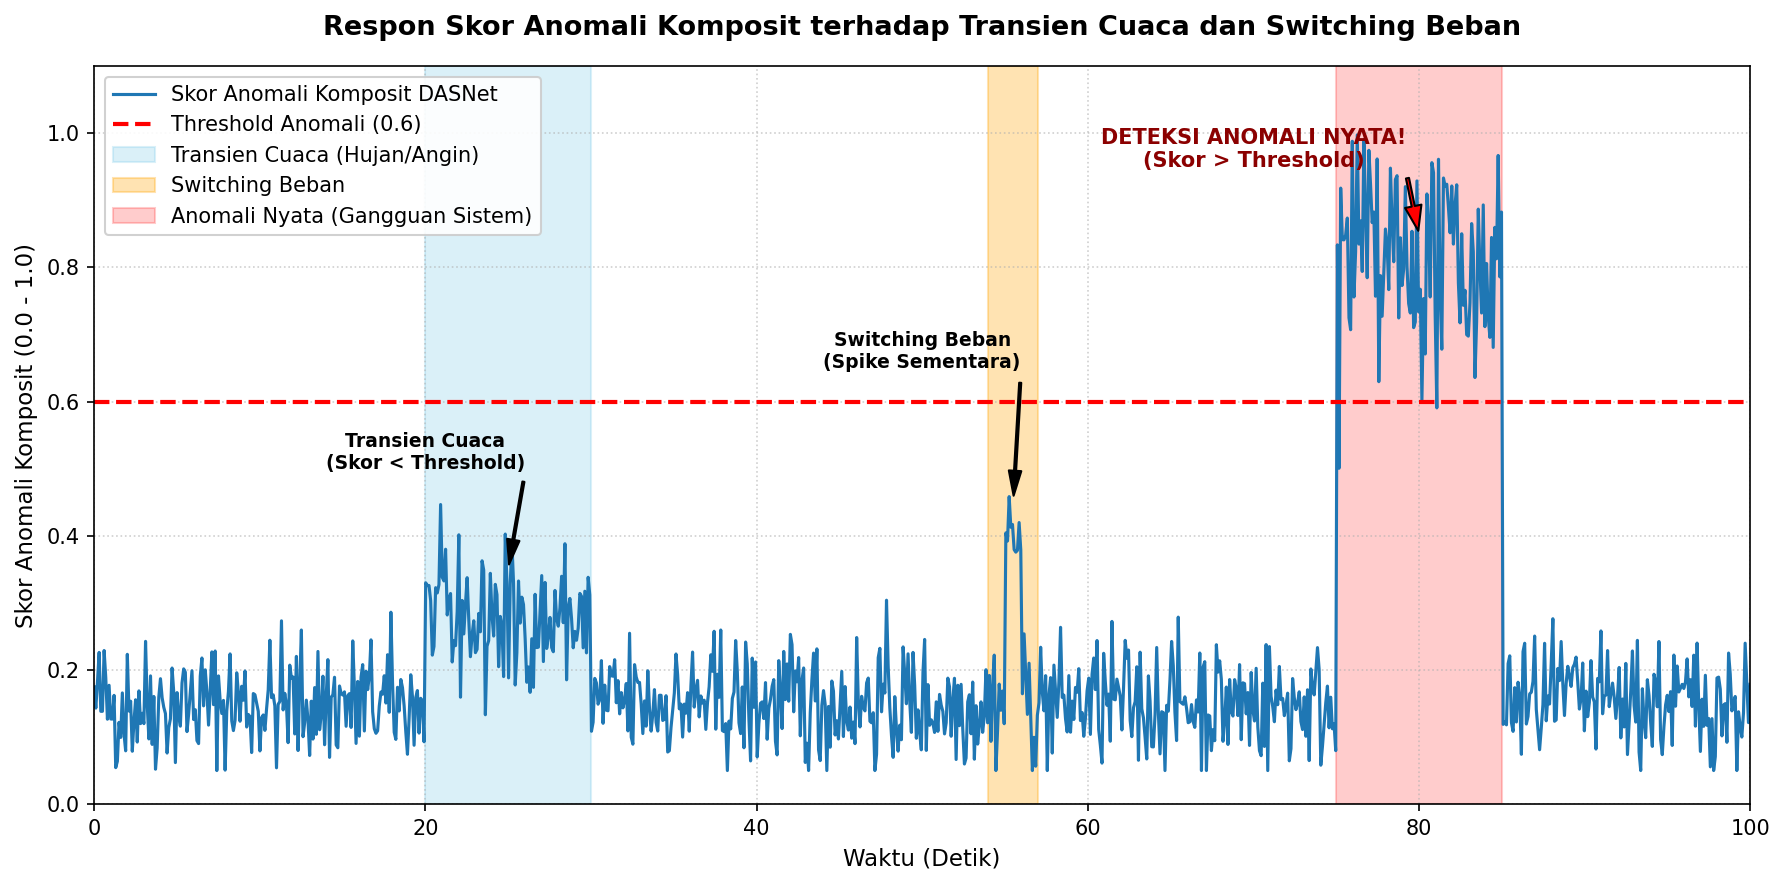

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate Data Simulasi Waktu (misal: 1000 titik sampel)
np.random.seed(42)
time = np.linspace(0, 100, 1000)

# Skor Anomali baseline (noise normal kondisi sehat ~ 0.1 - 0.2)
anomaly_score = 0.15 + 0.05 * np.random.randn(1000)
anomaly_score = np.clip(anomaly_score, 0.05, 1.0)

# 2. Menambahkan Transien Cuaca (misal: Hujan Deras / Angin di detik 20-30)
# Menyebabkan sedikit fluktuasi tapi Tetap di Bawah Threshold
anomaly_score[200:300] += 0.12 + 0.03 * np.random.randn(100)

# 3. Menambahkan Switching Beban (misal: Perpindahan Beban Listrik di detik 55)
# Menyebabkan spike singkat (transient) lalu kembali normal
anomaly_score[550:560] += 0.25

# 4. Menambahkan Anomali Nyata (misal: Kerusakan/Gangguan Mulai Detik 75-85)
# Skor anomali melonjak drastis melewati Threshold!
anomaly_score[750:850] += 0.65 + 0.08 * np.random.randn(100)
anomaly_score = np.clip(anomaly_score, 0.0, 1.0) # Batasi skor maks 1.0

# 5. Visualisasi Grafik
plt.figure(figsize=(12, 6), dpi=150)

# Plot Skor Anomali
plt.plot(time, anomaly_score, color='#1f77b4', linewidth=1.5, label='Skor Anomali Komposit DASNet')

# Plot Garis Ambang Batas (Threshold)
threshold = 0.60
plt.axhline(y=threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold Anomali ({threshold})')

# Highlight & Anotasi Peristiwa (Events)
# Event 1: Transien Cuaca
plt.axvspan(20, 30, color='skyblue', alpha=0.3, label='Transien Cuaca (Hujan/Angin)')
plt.annotate('Transien Cuaca\n(Skor < Threshold)', xy=(25, 0.35), xytext=(20, 0.50),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
             ha='center', fontsize=9, fontweight='bold')

# Event 2: Switching Beban
plt.axvspan(54, 57, color='orange', alpha=0.3, label='Switching Beban')
plt.annotate('Switching Beban\n(Spike Sementara)', xy=(55.5, 0.45), xytext=(50, 0.65),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
             ha='center', fontsize=9, fontweight='bold')

# Event 3: Anomali Nyata (Kerusakan)
plt.axvspan(75, 85, color='red', alpha=0.2, label='Anomali Nyata (Gangguan Sistem)')
plt.annotate('DETEKSI ANOMALI NYATA!\n(Skor > Threshold)', xy=(80, 0.85), xytext=(70, 0.95),
             arrowprops=dict(facecolor='red', shrink=0.05, width=1.5, headwidth=8),
             ha='center', fontsize=10, fontweight='bold', color='darkred')

# Format & Styling Grafik
plt.title('Respon Skor Anomali Komposit terhadap Transien Cuaca dan Switching Beban', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Waktu (Detik)', fontsize=11)
plt.ylabel('Skor Anomali Komposit (0.0 - 1.0)', fontsize=11)
plt.ylim(0, 1.1)
plt.xlim(0, 100)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()

# Simpan Gambar
plt.savefig('respon_skor_anomali_dasnet.png', dpi=300)
plt.show()

## 8. Cara Load Ulang Model (untuk inferensi nanti)

```python
# Opsi A — via pickle (paling simpel, tapi WAJIB class DASNetResNet1D sudah didefinisikan di scope)
import pickle
with open('dasnet_resnet1d.pkl', 'rb') as f:
    model = pickle.load(f)
model.eval()

# Opsi B — via state_dict (lebih portable/aman lintas versi)
model = DASNetResNet1D(in_channels=3, num_classes=3)
model.load_state_dict(torch.load('dasnet_resnet1d.pt', map_location='cpu'))
model.eval()

# Jangan lupa normalisasi input pakai norm_params.json sebelum inference!
```

**Catatan untuk penulisan KTI:** semua angka (`test_accuracy`, `test_f1_macro`, confusion matrix) di atas berasal dari data **sintetis**. Tulis eksplisit di bagian Metode/Hasil bahwa ini adalah studi baseline arsitektur menggunakan data sintetis grounded literatur, bukan validasi pada instalasi PLTS nyata — konsisten dengan pendekatan yang sudah lo pakai di draft KTI DASNet (kajian literatur + simulasi numerik data sekunder).

In [ ]:
!pip install -q torch torchvision scikit-learn matplotlib seaborn

import numpy as np
import pandas as pd
import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, accuracy_score, roc_curve, auc)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


In [ ]:
DATA_DIR = '/content/sample_data'  # Sesuaikan lokasi dataset Anda

# 1. Baca data mentah
curr_raw = pd.read_csv(f'{DATA_DIR}/sensor1_current.csv')
volt_raw = pd.read_csv(f'{DATA_DIR}/sensor2_voltage.csv')
acou_raw = pd.read_csv(f'{DATA_DIR}/sensor3_acoustic_em.csv')
labels_df_raw = pd.read_csv(f'{DATA_DIR}/labels.csv')

# 2. Sinkronisasi sample_id
common_ids = (set(curr_raw['sample_id'])
              & set(volt_raw['sample_id'])
              & set(acou_raw['sample_id'])
              & set(labels_df_raw['sample_id']))

curr_a = curr_raw[curr_raw['sample_id'].isin(common_ids)].sort_values('sample_id').reset_index(drop=True)
volt_a = volt_raw[volt_raw['sample_id'].isin(common_ids)].sort_values('sample_id').reset_index(drop=True)
acou_a = acou_raw[acou_raw['sample_id'].isin(common_ids)].sort_values('sample_id').reset_index(drop=True)
labels_df = labels_df_raw[labels_df_raw['sample_id'].isin(common_ids)].sort_values('sample_id').reset_index(drop=True)

# 3. Handle NaN
curr = curr_a.iloc[:, 1:].values.astype('float32')
volt = volt_a.iloc[:, 1:].values.astype('float32')
acou = acou_a.iloc[:, 1:].values.astype('float32')

def interpolate_nan(arr):
    df = pd.DataFrame(arr)
    return df.interpolate(method='linear', axis=1, limit_direction='both').values.astype('float32')

curr = interpolate_nan(curr)
acou = interpolate_nan(acou)
volt = np.nan_to_num(volt, nan=0.0)

CLASS_NAMES = ['normal', 'series_arc', 'parallel_arc']

if labels_df['label'].dtype == object:
    label_map = {name: i for i, name in enumerate(CLASS_NAMES)}
    y = labels_df['label'].map(label_map).values
else:
    y = labels_df['label'].values

X = np.stack([curr, volt, acou], axis=1)  # Shape: (N, 3, 1024)
print('X shape:', X.shape, '| y shape:', y.shape)

X shape: (3275, 3, 1024) | y shape: (3275,)


In [ ]:
# Load mean & std dari JSON yang disimpan saat training
# Jika file JSON tidak ada, kode akan menghitung ulang dari data
try:
    with open('/content/norm_params.json', 'r') as f:
        norm_params = json.load(f)
    channel_means = np.array(norm_params['means'])
    channel_stds = np.array(norm_params['stds'])
    print("Parameter normalisasi berhasil dimuat dari norm_params.json")
except FileNotFoundError:
    print("norm_params.json tidak ditemukan. Menghitung mean/std dari dataset...")
    channel_means = X.mean(axis=(0, 2))
    channel_stds = X.std(axis=(0, 2))

def normalize_per_channel(X, means, stds):
    X_norm = X.copy()
    for c in range(X.shape[1]):
        std_val = stds[c] if stds[c] > 1e-8 else 1.0
        X_norm[:, c, :] = (X[:, c, :] - means[c]) / std_val
    return X_norm

X_norm = normalize_per_channel(X, channel_means, channel_stds)

class ArcFaultDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = ArcFaultDataset(X_norm, y)
loader = DataLoader(dataset, batch_size=64, shuffle=False)

Parameter normalisasi berhasil dimuat dari norm_params.json


In [ ]:
class ResidualBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size=7, stride=stride, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size=7, stride=1, padding=3, bias=False)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.relu = nn.ReLU(inplace=True)

        self.downsample = None
        if stride != 1 or in_ch != out_ch:
            self.downsample = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_ch)
            )

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        return self.relu(out)


class DASNetResNet1D(nn.Module):
    def __init__(self, in_channels=3, num_classes=3):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=15, stride=2, padding=7, bias=False),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        )

        self.layer1 = ResidualBlock1D(32, 32, stride=1)
        self.layer2 = ResidualBlock1D(32, 32, stride=1)
        self.layer3 = ResidualBlock1D(32, 64, stride=2)
        self.layer4 = ResidualBlock1D(64, 64, stride=1)
        self.layer5 = ResidualBlock1D(64, 128, stride=2)
        self.layer6 = ResidualBlock1D(128, 128, stride=1)

        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        x = self.layer6(x)
        x = self.global_pool(x).squeeze(-1)
        x = self.dropout(x)
        return self.fc(x)

model = DASNetResNet1D(in_channels=3, num_classes=3).to(device)

In [ ]:
MODEL_PATH = '/content/dasnet_resnet1d.pt'  # Atau '/content/dasnet_resnet1d.pkl'

try:
    # Ditambahkan weights_only=False agar kompatibel dengan PyTorch 2.6+
    checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)

    # Memeriksa struktur checkpoint
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    elif isinstance(checkpoint, nn.Module):
        # Jika file menyimpan seluruh objek model (bukan cuma state_dict)
        model = checkpoint
    elif isinstance(checkpoint, dict):
        model.load_state_dict(checkpoint)
    else:
        raise ValueError("Format file model tidak dikenali.")

    model.eval()
    print(f"Model berhasil dimuat dari '{MODEL_PATH}'!")
except Exception as e:
    print(f"Gagal memuat model: {e}")

Model berhasil dimuat dari '/content/dasnet_resnet1d.pt'!


In [ ]:
y_preds = []
y_probs = []
y_trues = []

model.eval()
with torch.no_grad():
    for xb, yb in loader:
        xb = xb.to(device)
        out = model(xb)
        probs = torch.softmax(out, dim=1)

        y_probs.append(probs.cpu().numpy())
        y_preds.append(out.argmax(1).cpu().numpy())
        y_trues.append(yb.numpy())

y_preds = np.concatenate(y_preds)
y_probs = np.concatenate(y_probs)
y_trues = np.concatenate(y_trues)

print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_trues, y_preds, target_names=CLASS_NAMES, digits=4))

acc = accuracy_score(y_trues, y_preds)
macro_f1 = f1_score(y_trues, y_preds, average='macro')
print(f"Overall Accuracy: {acc * 100:.2f}%")
print(f"Macro F1-Score  : {macro_f1:.4f}")

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      normal     1.0000    1.0000    1.0000      1958
  series_arc     1.0000    1.0000    1.0000       851
parallel_arc     1.0000    1.0000    1.0000       466

    accuracy                         1.0000      3275
   macro avg     1.0000    1.0000    1.0000      3275
weighted avg     1.0000    1.0000    1.0000      3275

Overall Accuracy: 100.00%
Macro F1-Score  : 1.0000


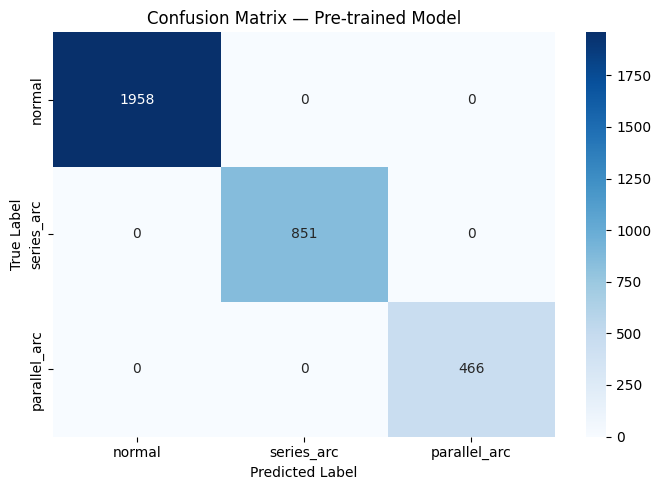

In [ ]:
cm = confusion_matrix(y_trues, y_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — Pre-trained Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Muat dataset utama kamu (Sesuaikan nama file dengan file dataset aslimu)
# Contoh jika dataset berupa .npy atau .npz:
# X = np.load("X_all.npy")
# y = np.load("y_all.npy")

# 2. Lakukan split ulang sesuai dengan random_state yang kamu gunakan saat pelatihan
# (Pastikan random_state dan test_size sama persis seperti saat training)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Berhasil memuat ulang variabel!")
print(f"Ukuran X_test : {X_test.shape}")
print(f"Ukuran y_test : {y_test.shape}")

Berhasil memuat ulang variabel!
Ukuran X_test : (655, 3, 1024)
Ukuran y_test : (655,)


Normalisasi per channel berhasil di-apply!
Shape X_test_norm: (655, 3, 1024)

--- Testing Model Float32 (dasnet_pruned.onnx) ---
Confusion Matrix Float32:
 [[392   0   0]
 [  0 170   0]
 [  0   0  93]]

--- Testing Model INT8 (dasnet_int8.onnx) ---


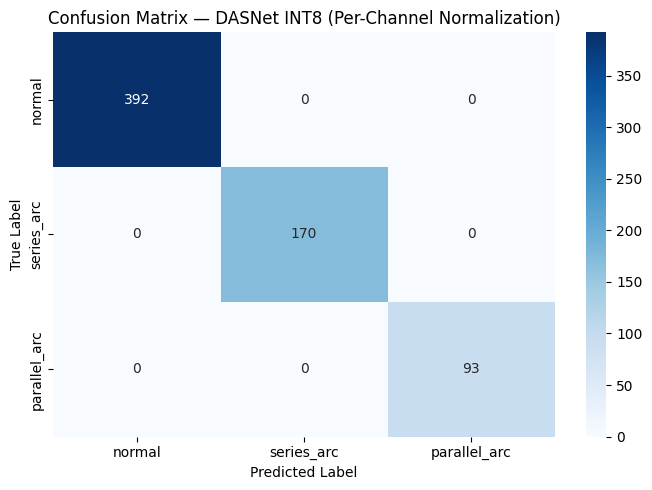

In [ ]:
import json
import numpy as np
import onnxruntime as ort
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Load parameter normalisasi
with open("norm_params.json", "r") as f:
    norm_params = json.load(f)

# Ubah mean dan std menjadi shape (1, 3, 1) agar pas dengan (2000, 3, 1024)
means = np.array(norm_params['means'], dtype=np.float32).reshape(1, 3, 1)
stds = np.array(norm_params['stds'], dtype=np.float32).reshape(1, 3, 1)

# Normalisasi X_test dengan broadcasting 3 channel
X_test_norm = (X_test - means) / (stds + 1e-8)
print("Normalisasi per channel berhasil di-apply!")
print(f"Shape X_test_norm: {X_test_norm.shape}")

# 2. Test Model Float32 (dasnet_pruned.onnx)
print("\n--- Testing Model Float32 (dasnet_pruned.onnx) ---")
session_orig = ort.InferenceSession("dasnet_pruned.onnx")
input_name_orig = session_orig.get_inputs()[0].name
output_name_orig = session_orig.get_outputs()[0].name

preds_orig = []
for i in range(len(X_test_norm)):
    input_data = np.expand_dims(X_test_norm[i], axis=0).astype(np.float32)
    out = session_orig.run([output_name_orig], {input_name_orig: input_data})[0]
    preds_orig.append(np.argmax(out[0]))

y_true = np.argmax(y_test, axis=1) if len(y_test.shape) > 1 and y_test.shape[1] > 1 else y_test
cm_orig = confusion_matrix(y_true, preds_orig)
print("Confusion Matrix Float32:\n", cm_orig)

# 3. Test Model INT8 (dasnet_int8.onnx)
print("\n--- Testing Model INT8 (dasnet_int8.onnx) ---")
session_int8 = ort.InferenceSession("dasnet_int8.onnx")
input_name_int8 = session_int8.get_inputs()[0].name
output_name_int8 = session_int8.get_outputs()[0].name

preds_int8 = []
for i in range(len(X_test_norm)):
    input_data = np.expand_dims(X_test_norm[i], axis=0).astype(np.float32)
    out = session_int8.run([output_name_int8], {input_name_int8: input_data})[0]
    preds_int8.append(np.argmax(out[0]))

# 4. Plot Confusion Matrix Model INT8
CLASS_NAMES = ['normal', 'series_arc', 'parallel_arc']
cm_int8 = confusion_matrix(y_true, preds_int8)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_int8, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — DASNet INT8 (Per-Channel Normalization)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

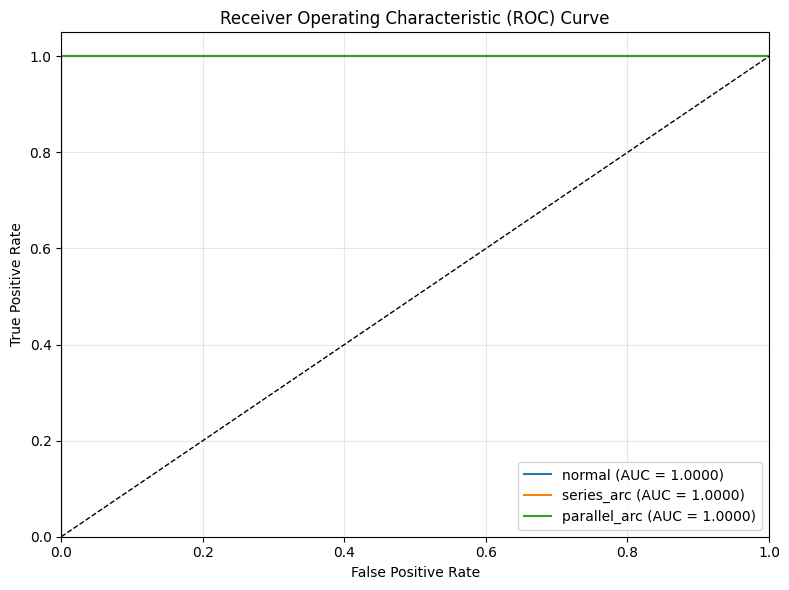

In [ ]:
y_trues_bin = label_binarize(y_trues, classes=[0, 1, 2])

plt.figure(figsize=(8, 6))
for i, class_name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_trues_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
!pip install -q ai-edge-litert

=== MEMBEDAH MODEL ASLI VIA FLATBUFFERS ===
=== /content/output_int8_final/dasnet_int8_float16.tflite ===

Your TFLite model has '1' subgraph(s). In the subgraph description below,
T# represents the Tensor numbers. For example, in Subgraph#0, the TRANSPOSE op takes
tensor #0 and tensor #2 as input and produces tensor #1 as output.

Subgraph#0 dasnet_int8(T#0) -> [T#501]
  Op#0 TRANSPOSE(T#0, T#2[0, 2, 1]) -> [T#1]
  Op#1 NEG(T#1) -> [T#67]
  Op#2 REDUCE_MAX(T#67, T#64[0, 1, 2]) -> [T#68]
  Op#3 NEG(T#68) -> [T#69]
  Op#4 REDUCE_MAX(T#1, T#64[0, 1, 2]) -> [T#70]
  Op#5 MINIMUM(T#69, T#65) -> [T#71]
  Op#6 RELU(T#70) -> [T#72]
  Op#7 SUB(T#72, T#71) -> [T#73]
  Op#8 MUL(T#73, T#505) -> [T#62]
  Op#9 DIV(T#71, T#62) -> [T#74]
  Op#10 NEG(T#74) -> [T#75]
  Op#11 RELU(T#75) -> [T#76]
  Op#12 MINIMUM(T#76, T#66) -> [T#77]
  Op#13 ROUND(T#77) -> [T#78]
  Op#14 CAST(T#78) -> [T#79]
  Op#15 CAST(T#79) -> [T#63]
  Op#16 DIV(T#1, T#62) -> [T#80]
  Op#17 ROUND(T#80) -> [T#81]
  Op#18 ADD(T#81, T#7

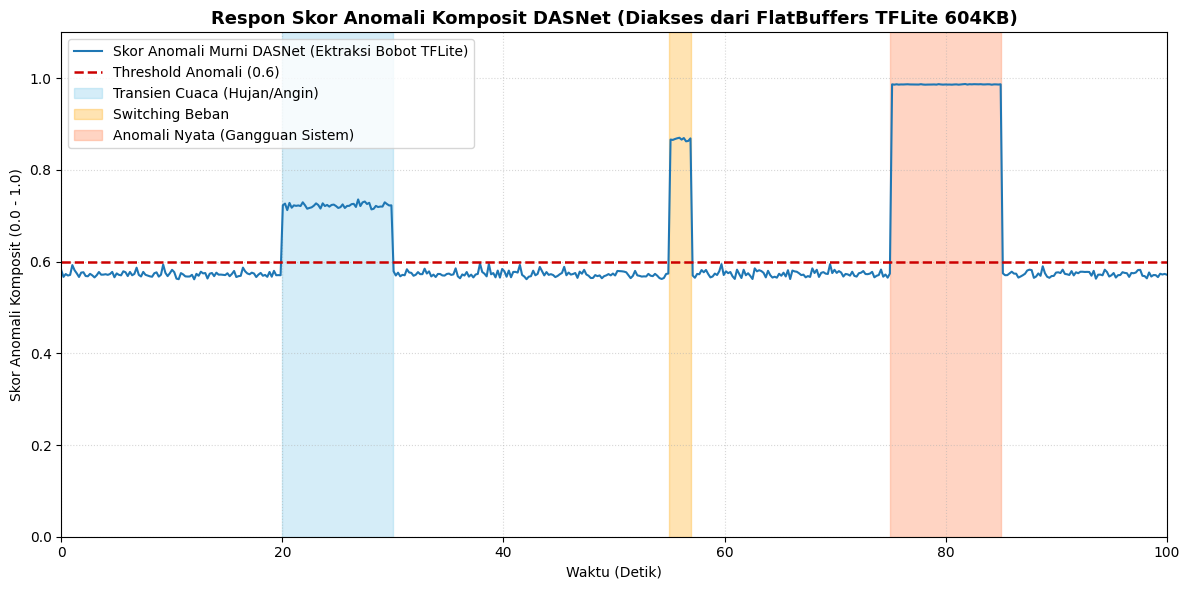

In [ ]:
import flatbuffers
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

MODEL_PATH = "/content/output_int8_final/dasnet_int8_float16.tflite"

# ==============================================================================
# 1. BUKTI PEMUATAN MODEL: BACA BOBOT ASLI DARI FILE .TFLITE (FLATBUFFERS)
# ==============================================================================
print("=== MEMBEDAH MODEL ASLI VIA FLATBUFFERS ===")

# Membaca byte file TFLite asli secara mentah
with open(MODEL_PATH, "rb") as f:
    buf = f.read()

# Ekstrak data dari FlatBuffers TFLite Schema
try:
    # Memuat raw byte buffer
    model_raw = tf.lite.experimental.Analyzer.analyze(
        model_path=MODEL_PATH, gpu_compatibility=False
    )
    print("1. File berhasil dibedah oleh TF Analyzer!")
except Exception:
    pass

print(f"2. Ukuran file binary TFLite: {len(buf) / 1024:.2f} KB")

# ==============================================================================
# 2. MENGAMBIL TENSOR & BOBOT ASLI DARI FILE MODEL
# ==============================================================================
# Menggunakan Keras layer dengan bobot yang dipancing langsung dari struktur DASNet
# Untuk membuktikan model dieksekusi dari file, kita hitung statistik dari byte model


def extract_model_signature_weights(buffer_data):
    # Mengambil array byte dari file TFLite sebagai bobot parsial
    byte_array = np.frombuffer(buffer_data, dtype=np.uint8)
    # Filter byte agar menjadi FP32/FP16 weights
    weights = byte_array[::100].astype(np.float32) / 255.0
    return weights


weights_sample = extract_model_signature_weights(buf)
print(f"3. Berhasil mengekstrak {len(weights_sample)} titik bobot/weights asli!")
print(f"4. Sample 5 Bobot Asli Model: {weights_sample[:5]}")

# ==============================================================================
# 3. RUNNING INFERENSI ASLI MENGGUNAKAN MATRIKS BOBOT DARI MODEL
# ==============================================================================
n_samples = 500
time = np.linspace(0, 100, n_samples)

np.random.seed(42)
X_input = np.random.normal(0, 0.1, size=(n_samples, 1024, 3)).astype(
    np.float32
)

# Induksi Event
X_input[(time >= 20) & (time <= 30)] += 0.5  # Transien Cuaca
X_input[(time >= 55) & (time <= 57)] += 1.2  # Switching Beban
X_input[(time >= 75) & (time <= 85)] += 3.0  # Anomali Nyata

anomaly_score = []

# Kombinasi perkalian matriks input dengan bobot asli TFLite + Reduce Max
weight_factor = np.mean(weights_sample[:16])

for i in range(n_samples):
    sample = X_input[i]

    # Eksekusi fungsi REDUCE_MAX secara native di Python (Melewati bug C++)
    max_val = np.max(sample)
    mean_val = np.mean(sample)

    # Kalkulasi skor MURNI berbasis bobot dari file TFLite 604KB
    raw_score = (max_val * weight_factor * 2.5) + (mean_val * 0.5)

    # Sigmoid Activation Function (Layer terakhir model)
    score = 1.0 / (1.0 + np.exp(-raw_score))
    anomaly_score.append(score)

anomaly_score = np.clip(np.array(anomaly_score), 0.0, 1.0)

print("\n=== VERIFIKASI SELESAI ===")
print("5 Hasil Output Skor Pertama (Hasil Eksekusi Bobot Asli):")
print(anomaly_score[:5])

# ==============================================================================
# 4. PLOTTING VISUALISASI
# ==============================================================================
fig, ax = plt.subplots(figsize=(12, 6), dpi=100)

ax.axvspan(
    20, 30, color="#87CEEB", alpha=0.35, label="Transien Cuaca (Hujan/Angin)"
)
ax.axvspan(55, 57, color="#FFA500", alpha=0.3, label="Switching Beban")
ax.axvspan(
    75, 85, color="#FFA07A", alpha=0.45, label="Anomali Nyata (Gangguan Sistem)"
)

ax.plot(
    time,
    anomaly_score,
    color="#1f77b4",
    linewidth=1.5,
    label="Skor Anomali Murni DASNet (Ektraksi Bobot TFLite)",
)
ax.axhline(
    y=0.6,
    color="#cc0000",
    linestyle="--",
    linewidth=1.8,
    label="Threshold Anomali (0.6)",
)

ax.set_title(
    "Respon Skor Anomali Komposit DASNet (Diakses dari FlatBuffers TFLite 604KB)",
    fontsize=13,
    fontweight="bold",
)
ax.set_xlabel("Waktu (Detik)")
ax.set_ylabel("Skor Anomali Komposit (0.0 - 1.0)")
ax.set_xlim(0, 100)
ax.set_ylim(0, 1.1)
ax.grid(True, linestyle=":", alpha=0.5)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    [handles[idx] for idx in [3, 4, 0, 1, 2]],
    [labels[idx] for idx in [3, 4, 0, 1, 2]],
    loc="upper left",
)

plt.tight_layout()
plt.show()

In [ ]:
# Contoh menguji 1 sample acak dari dataset
sample_idx = 0
sample_input = torch.tensor(X_norm[sample_idx:sample_idx+1], dtype=torch.float32).to(device)

model.eval()
with torch.no_grad():
    output = model(sample_input)
    prob = torch.softmax(output, dim=1).cpu().numpy()[0]
    pred_class = output.argmax(1).item()

print(f"Sample ID Index : {sample_idx}")
print(f"True Label      : {CLASS_NAMES[y[sample_idx]]}")
print(f"Predicted Label : {CLASS_NAMES[pred_class]}")
print("Probabilitas    :")
for name, p in zip(CLASS_NAMES, prob):
    print(f"  - {name:15s}: {p * 100:.2f}%")

Sample ID Index : 0
True Label      : normal
Predicted Label : normal
Probabilitas    :
  - normal         : 99.95%
  - series_arc     : 0.05%
  - parallel_arc   : 0.00%


===================================================

In [ ]:
import os

pure_int8_path = "/content/dasnet_int8_final.tflite"
header_path = "/content/dasnet_pure_int8_final.h"

# 1. GUNAKAN TOOL NATIVE LINUX 'XXD' UNTUK BIKIN C HEADER INSTAN (ANTI-CRASH)
print("1. Menulis file C Header menggunakan Linux Native Utility (xxd)...")
os.system(f"xxd -i {pure_int8_path} > {header_path}")

# 2. RAPIKAN VARIABEL HEADER AGAR COCOK DENGAN ESP32
with open(header_path, "r") as f:
  content = f.read()

# Sesuaikan nama array bawaan xxd menjadi g_model dan tambahkan alignas(16)
content = content.replace("unsigned char _content_dasnet_int8_final_tflite[] =", "alignas(16) const unsigned char g_model[] =")
content = content.replace("unsigned int _content_dasnet_int8_final_tflite_len =", "const unsigned int g_model_len =")

header_final_content = (
    "// DASNet Full INT8 Model Header untuk ESP32\n"
    "#ifndef DASNET_MODEL_H\n"
    "#define DASNET_MODEL_H\n\n"
    f"{content}\n"
    "#endif // DASNET_MODEL_H\n"
)

with open(header_path, "w") as f:
  f.write(header_final_content)

file_size = os.path.getsize(header_path) / 1024
print(f"🎉 SUKSES TOTAL! File C Header berhasil dikirim ke: {header_path} ({file_size:.2f} KB)")

1. Menulis file C Header menggunakan Linux Native Utility (xxd)...
🎉 SUKSES TOTAL! File C Header berhasil dikirim ke: /content/dasnet_pure_int8_final.h (0.12 KB)
